# Superstore Sales Analysis
## Notebook 06: Discount & Profitability Analysis

### Objective
This notebook analyzes the relationship between discounts 
and profitability across different dimensions.

### Business Questions
1. What is the overall relationship between discount and profit?
2. Which discount levels cause losses?
3. Which categories are most affected by discounting?
4. Which sub-categories have the highest average discount?
5. How does discount impact profit across regions?
6. How does discount impact profit across segments?
7. What are the recommended discount thresholds?

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create folders if not exist
os.makedirs('images', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# LOAD CLEANED DATA

df = pd.read_csv('data/processed/superstore_cleaned.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print("Data loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully
Shape: (9994, 27)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Profit Margin (%),Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,Nov,4,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,Nov,4,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,Jun,2,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,Oct,4,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,Oct,4,11.25,7


In [3]:
# HELPER FUNCTIONS

def format_currency(value):
    return f"${value:,.2f}"

def format_percent(value):
    return f"{value:.2f}%"

def format_number(value):
    return f"{value:,.0f}"

def save_fig(filename):
    plt.savefig(f'images/{filename}', dpi=150, bbox_inches='tight')
    print(f"Saved: images/{filename}")

print("Helper functions ready")

Helper functions ready


## 1. Discount Overview

Before analyzing the impact of discounts, we first 
understand the overall distribution of discounts 
across the dataset.

In [4]:
# DISCOUNT OVERVIEW

# Convert discount to percentage
df['Discount_%'] = (df['Discount'] * 100).round(2)

# Basic stats
print("=" * 60)
print("DISCOUNT DISTRIBUTION OVERVIEW")
print("=" * 60)

print(f"\nTotal records:          {len(df):,}")
print(f"Records with discount:  "
      f"{len(df[df['Discount'] > 0]):,} "
      f"({len(df[df['Discount'] > 0]) / len(df) * 100:.1f}%)")
print(f"Records no discount:    "
      f"{len(df[df['Discount'] == 0]):,} "
      f"({len(df[df['Discount'] == 0]) / len(df) * 100:.1f}%)")

print(f"\nDiscount Statistics:")
print(f"  Mean:    {format_percent(df['Discount_%'].mean())}")
print(f"  Median:  {format_percent(df['Discount_%'].median())}")
print(f"  Max:     {format_percent(df['Discount_%'].max())}")
print(f"  Min:     {format_percent(df['Discount_%'].min())}")

# Unique discount values
unique_discounts = sorted(df['Discount'].unique())
print(f"\nUnique discount levels ({len(unique_discounts)} total):")
print([f"{d*100:.0f}%" for d in unique_discounts])

DISCOUNT DISTRIBUTION OVERVIEW

Total records:          9,994
Records with discount:  5,196 (52.0%)
Records no discount:    4,798 (48.0%)

Discount Statistics:
  Mean:    15.62%
  Median:  20.00%
  Max:     80.00%
  Min:     0.00%

Unique discount levels (12 total):
['0%', '10%', '15%', '20%', '30%', '32%', '40%', '45%', '50%', '60%', '70%', '80%']


Saved: images/discount_distribution.png


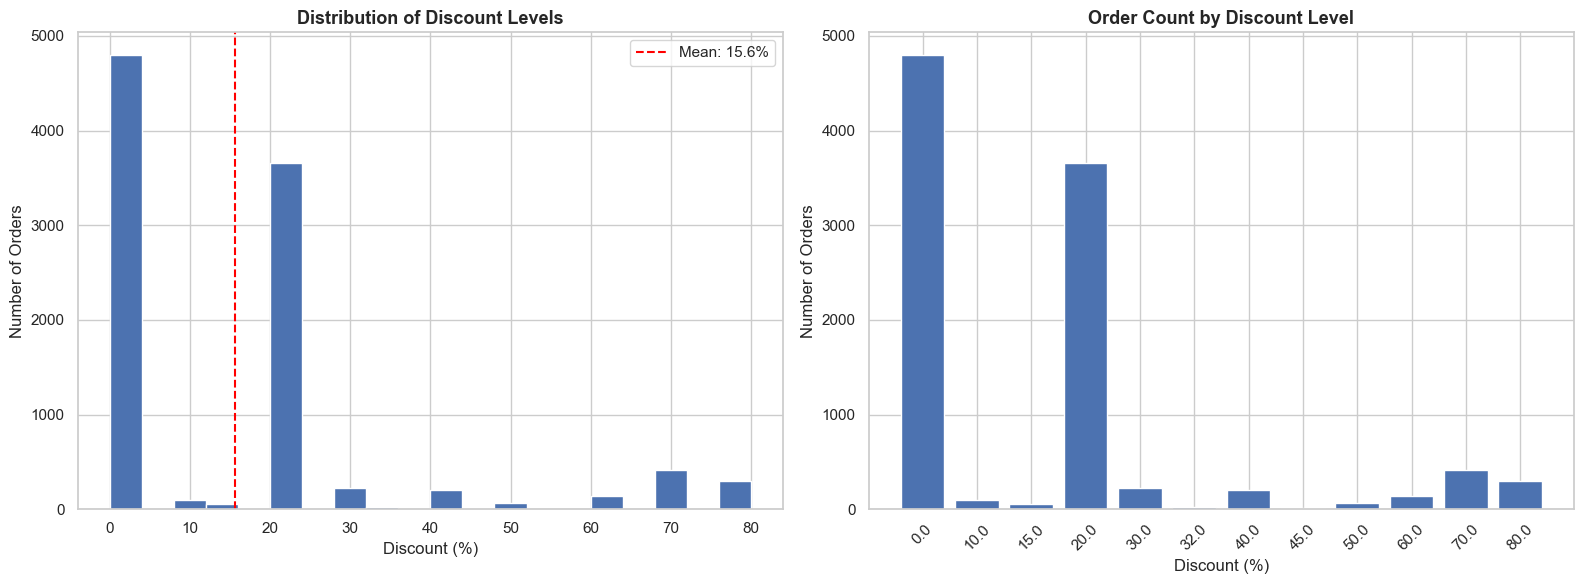

In [5]:
# DISCOUNT DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(
    df['Discount_%'],
    bins=20,
    color='#4C72B0',
    edgecolor='white'
)

axes[0].axvline(
    df['Discount_%'].mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Mean: {df['Discount_%'].mean():.1f}%"
)

axes[0].set_title('Distribution of Discount Levels',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Count by discount level
discount_counts = df.groupby('Discount_%').size().reset_index(
    name='Count'
)

axes[1].bar(
    discount_counts['Discount_%'].astype(str),
    discount_counts['Count'],
    color='#4C72B0',
    edgecolor='white'
)

axes[1].set_title('Order Count by Discount Level',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('discount_distribution.png')
plt.show()

## 2. Relationship Between Discount and Profit

Business question:

**Does offering a higher discount lead to lower profit?**

Saved: images/discount_vs_profit_scatter.png


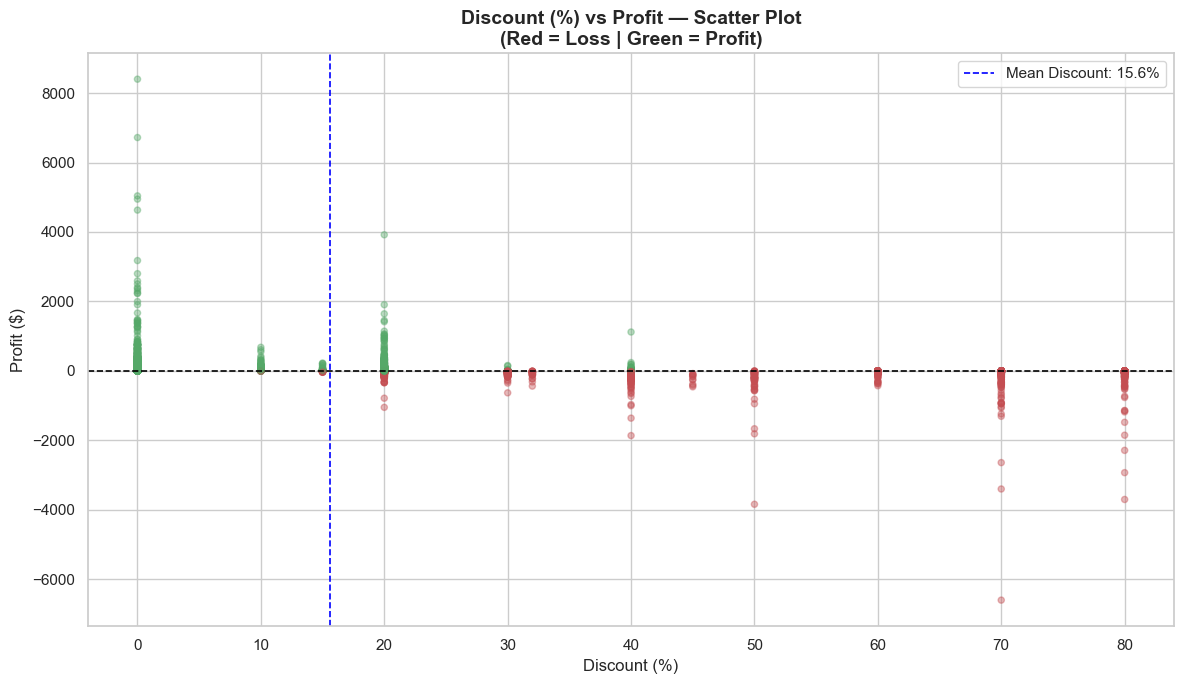

In [6]:
# DISCOUNT vs PROFIT SCATTER

plt.figure(figsize=(12, 7))

# Color by positive/negative profit
colors = [
    '#C44E52' if p < 0 else '#55A868'
    for p in df['Profit']
]

plt.scatter(
    df['Discount_%'],
    df['Profit'],
    c=colors,
    alpha=0.4,
    s=20
)

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.axvline(
    df['Discount_%'].mean(),
    color='blue',
    linewidth=1.2,
    linestyle='--',
    label=f"Mean Discount: {df['Discount_%'].mean():.1f}%"
)

plt.title('Discount (%) vs Profit — Scatter Plot\n'
          '(Red = Loss | Green = Profit)',
          fontsize=14, fontweight='bold')
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')
plt.legend()

plt.tight_layout()
save_fig('discount_vs_profit_scatter.png')
plt.show()

In [7]:
# CORRELATION: DISCOUNT vs PROFIT

correlation = df['Discount'].corr(df['Profit'])

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)
print(f"\nCorrelation between Discount and Profit: {correlation:.4f}")
print()

if correlation < -0.5:
    print("→ Strong NEGATIVE correlation.")
    print("  Higher discounts are strongly associated "
          "with lower profit.")
elif correlation < -0.3:
    print("→ Moderate NEGATIVE correlation.")
    print("  Higher discounts tend to reduce profit.")
elif correlation < 0:
    print("→ Weak NEGATIVE correlation.")
    print("  Some negative relationship between "
          "discount and profit.")
else:
    print("→ Positive or no correlation.")

CORRELATION ANALYSIS

Correlation between Discount and Profit: -0.2195

→ Weak NEGATIVE correlation.
  Some negative relationship between discount and profit.


In [ ]:
### Insight



### Recommendation



## 3. Discount Bands Analysis

Business question:

**Which discount levels cause the most losses?**

We group orders into discount bands to analyze 
average profit at each level.

In [8]:
# DISCOUNT BANDS

def assign_discount_band(discount):
    if discount == 0:
        return '0% — No Discount'
    elif discount <= 10:
        return '1–10% — Very Low'
    elif discount <= 20:
        return '11–20% — Low'
    elif discount <= 30:
        return '21–30% — Medium'
    elif discount <= 40:
        return '31–40% — High'
    else:
        return '41%+ — Very High'

df['Discount_Band'] = df['Discount_%'].apply(assign_discount_band)

# Define order for display
band_order = [
    '0% — No Discount',
    '1–10% — Very Low',
    '11–20% — Low',
    '21–30% — Medium',
    '31–40% — High',
    '41%+ — Very High'
]

discount_band_analysis = df.groupby('Discount_Band').agg(
    Total_Orders  = ('Order ID',  'count'),
    Total_Sales   = ('Sales',     'sum'),
    Total_Profit  = ('Profit',    'sum'),
    Avg_Profit    = ('Profit',    'mean'),
    Avg_Sales     = ('Sales',     'mean')
).reset_index()

discount_band_analysis['Profit_Margin_%'] = (
    discount_band_analysis['Total_Profit'] /
    discount_band_analysis['Total_Sales'] * 100
).round(2)

# Sort by band order
discount_band_analysis['Discount_Band'] = pd.Categorical(
    discount_band_analysis['Discount_Band'],
    categories=band_order,
    ordered=True
)

discount_band_analysis = discount_band_analysis.sort_values(
    'Discount_Band'
).reset_index(drop=True)

discount_band_analysis

,Discount_Band,Total_Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Sales,Profit_Margin_%
0,0% — No Discount,4798,1087908.47,320987.60,66.90,226.74,29.51
1,1–10% — Very Low,94,54369.35,9029.18,96.06,578.40,16.61
2,11–20% — Low,3709,792152.89,91756.30,24.74,213.58,11.58
3,21–30% — Medium,227,103226.65,-10369.28,-45.68,454.74,-10.05
4,31–40% — High,233,130911.24,-25448.19,-109.22,561.85,-19.44
5,41%+ — Very High,933,128632.25,-99558.59,-106.71,137.87,-77.40


In [9]:
# PRINT DISCOUNT BAND SUMMARY

print("=" * 70)
print("DISCOUNT BAND ANALYSIS")
print("=" * 70)

for _, row in discount_band_analysis.iterrows():
    status = "⚠️ LOSS" if row['Total_Profit'] < 0 else "✅ PROFIT"
    print(f"\n{status} | Band: {row['Discount_Band']}")
    print(f"  Orders:         {format_number(row['Total_Orders'])}")
    print(f"  Total Sales:    {format_currency(row['Total_Sales'])}")
    print(f"  Total Profit:   {format_currency(row['Total_Profit'])}")
    print(f"  Avg Profit:     {format_currency(row['Avg_Profit'])}")
    print(f"  Profit Margin:  {format_percent(row['Profit_Margin_%'])}")

DISCOUNT BAND ANALYSIS

✅ PROFIT | Band: 0% — No Discount
  Orders:         4,798
  Total Sales:    $1,087,908.47
  Total Profit:   $320,987.60
  Avg Profit:     $66.90
  Profit Margin:  29.51%

✅ PROFIT | Band: 1–10% — Very Low
  Orders:         94
  Total Sales:    $54,369.35
  Total Profit:   $9,029.18
  Avg Profit:     $96.06
  Profit Margin:  16.61%

✅ PROFIT | Band: 11–20% — Low
  Orders:         3,709
  Total Sales:    $792,152.89
  Total Profit:   $91,756.30
  Avg Profit:     $24.74
  Profit Margin:  11.58%

⚠️ LOSS | Band: 21–30% — Medium
  Orders:         227
  Total Sales:    $103,226.65
  Total Profit:   $-10,369.28
  Avg Profit:     $-45.68
  Profit Margin:  -10.05%

⚠️ LOSS | Band: 31–40% — High
  Orders:         233
  Total Sales:    $130,911.24
  Total Profit:   $-25,448.19
  Avg Profit:     $-109.22
  Profit Margin:  -19.44%

⚠️ LOSS | Band: 41%+ — Very High
  Orders:         933
  Total Sales:    $128,632.25
  Total Profit:   $-99,558.59
  Avg Profit:     $-106.71
  P

Saved: images/avg_profit_by_discount_band.png


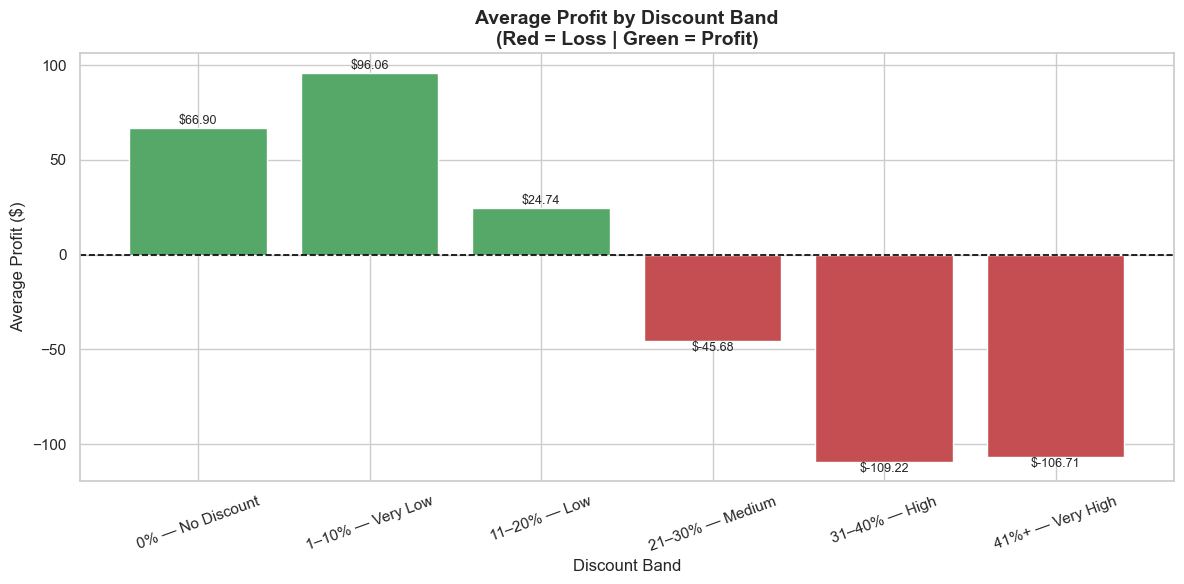

In [10]:
# AVG PROFIT BY DISCOUNT BAND

colors = [
    '#C44E52' if p < 0 else '#55A868'
    for p in discount_band_analysis['Avg_Profit']
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    discount_band_analysis['Discount_Band'],
    discount_band_analysis['Avg_Profit'],
    color=colors,
    edgecolor='white'
)

for bar in bars:
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 0.5 if height >= 0 else -0.5
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + offset,
        format_currency(height),
        ha='center', va=va, fontsize=9
    )

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.title('Average Profit by Discount Band\n'
          '(Red = Loss | Green = Profit)',
          fontsize=14, fontweight='bold')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation=20)

plt.tight_layout()
save_fig('avg_profit_by_discount_band.png')
plt.show()

Saved: images/profit_margin_by_discount_band.png


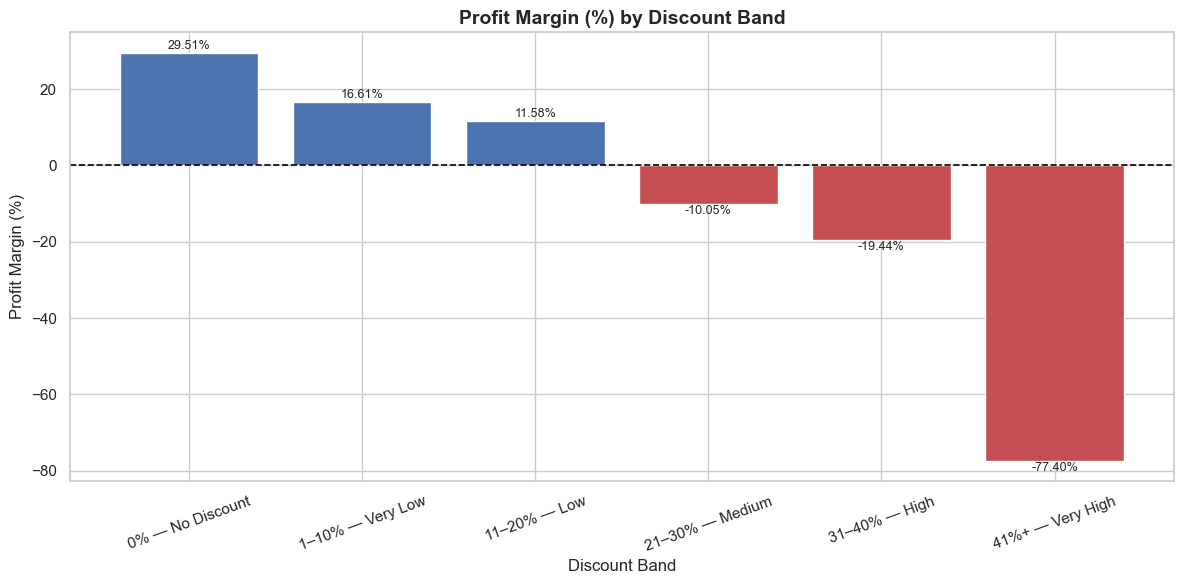

In [11]:
# PROFIT MARGIN BY DISCOUNT BAND
colors_margin = [
    '#C44E52' if m < 0 else '#4C72B0'
    for m in discount_band_analysis['Profit_Margin_%']
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    discount_band_analysis['Discount_Band'],
    discount_band_analysis['Profit_Margin_%'],
    color=colors_margin,
    edgecolor='white'
)

for bar in bars:
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 0.3 if height >= 0 else -0.3
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + offset,
        format_percent(height),
        ha='center', va=va, fontsize=9
    )

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.title('Profit Margin (%) by Discount Band',
          fontsize=14, fontweight='bold')
plt.xlabel('Discount Band')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=20)

plt.tight_layout()
save_fig('profit_margin_by_discount_band.png')
plt.show()

In [12]:
discount_band_analysis.to_csv(
    'reports/tables/discount_band_analysis.csv', index=False
)

print("Discount band analysis table saved")

Discount band analysis table saved


In [ ]:
### Insight



### Recommendation



## 4. Discount Impact by Category

Business question:

**Which categories are most affected by discounting?**

In [13]:
# DISCOUNT IMPACT BY CATEGORY

category_discount = df.groupby('Category').agg(
    Total_Orders    = ('Order ID', 'count'),
    Total_Sales     = ('Sales',    'sum'),
    Total_Profit    = ('Profit',   'sum'),
    Avg_Discount    = ('Discount', 'mean'),
    Avg_Profit      = ('Profit',   'mean')
).reset_index()

category_discount['Profit_Margin_%'] = (
    category_discount['Total_Profit'] /
    category_discount['Total_Sales'] * 100
).round(2)

category_discount['Avg_Discount_%'] = (
    category_discount['Avg_Discount'] * 100
).round(2)

category_discount = category_discount.sort_values(
    'Avg_Discount_%', ascending=False
).reset_index(drop=True)

category_discount

,Category,Total_Orders,Total_Sales,Total_Profit,Avg_Discount,Avg_Profit,Profit_Margin_%,Avg_Discount_%
0,Furniture,2121,741999.80,18451.27,0.17,8.70,2.49,17.39
1,Office Supplies,6026,719047.03,122490.80,0.16,20.33,17.04,15.73
2,Technology,1847,836154.03,145454.95,0.13,78.75,17.40,13.23


C:\Users\admin\AppData\Local\Temp\ipykernel_12788\2463630290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: images/category_discount_profit_margin.png


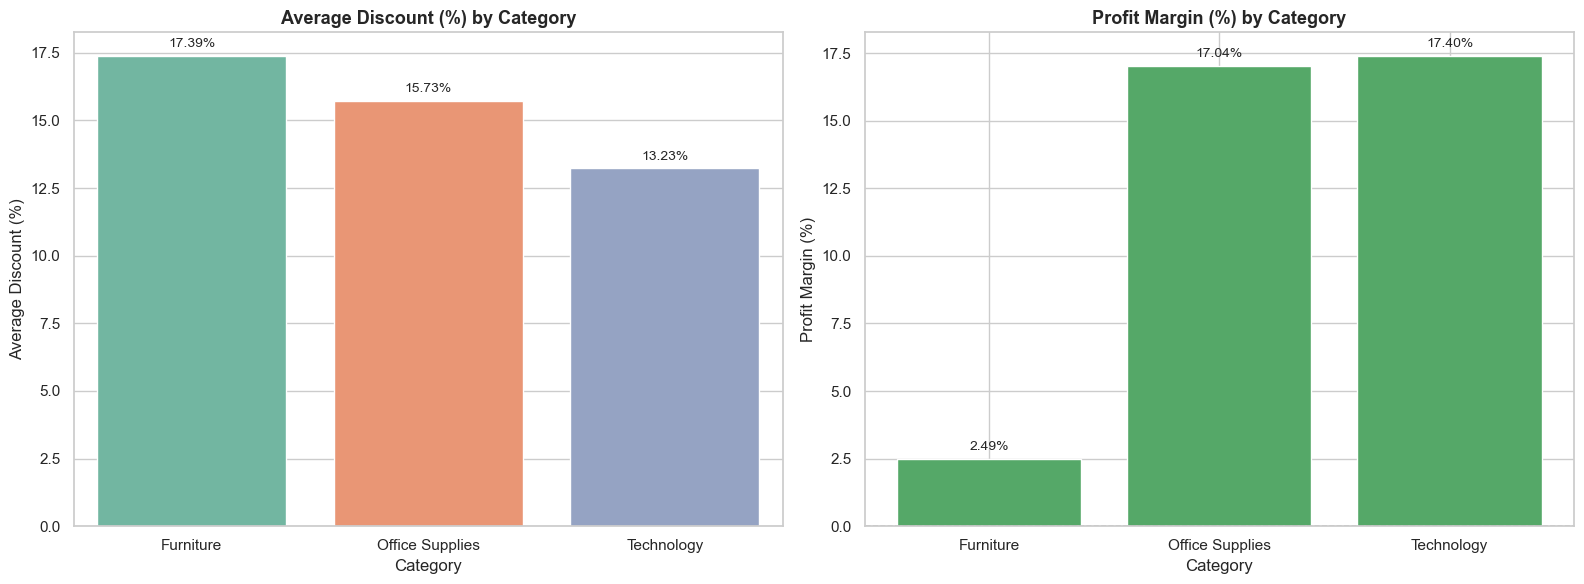

In [14]:
# DISCOUNT vs PROFIT MARGIN BY CATEGORY

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg Discount by Category
sns.barplot(
    data=category_discount,
    x='Category',
    y='Avg_Discount_%',
    ax=axes[0],
    palette='Set2'
)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        format_percent(bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )

axes[0].set_title('Average Discount (%) by Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Discount (%)')

# Profit Margin by Category
colors_cat = [
    '#C44E52' if m < 0 else '#55A868'
    for m in category_discount['Profit_Margin_%']
]

axes[1].bar(
    category_discount['Category'],
    category_discount['Profit_Margin_%'],
    color=colors_cat,
    edgecolor='white'
)

for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        format_percent(height),
        ha='center', va='bottom', fontsize=10
    )

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Profit Margin (%) by Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit Margin (%)')

plt.tight_layout()
save_fig('category_discount_profit_margin.png')
plt.show()

In [15]:
# DISCOUNT IMPACT BY SUB-CATEGORY

subcat_discount = df.groupby(
    ['Category', 'Sub-Category']
).agg(
    Total_Orders = ('Order ID', 'count'),
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Avg_Discount = ('Discount', 'mean'),
    Avg_Profit   = ('Profit',   'mean')
).reset_index()

subcat_discount['Profit_Margin_%'] = (
    subcat_discount['Total_Profit'] /
    subcat_discount['Total_Sales'] * 100
).round(2)

subcat_discount['Avg_Discount_%'] = (
    subcat_discount['Avg_Discount'] * 100
).round(2)

subcat_discount = subcat_discount.sort_values(
    'Avg_Discount_%', ascending=False
).reset_index(drop=True)

subcat_discount

,Category,Sub-Category,Total_Orders,Total_Sales,Total_Profit,Avg_Discount,Avg_Profit,Profit_Margin_%,Avg_Discount_%
0,Office Supplies,Binders,1523,203412.73,30221.76,0.37,19.84,14.86,37.23
1,Technology,Machines,115,189238.63,3384.76,0.31,29.43,1.79,30.61
2,Furniture,Tables,319,206965.53,-17725.48,0.26,-55.57,-8.56,26.13
3,Furniture,Bookcases,228,114880.00,-3472.56,0.21,-15.23,-3.02,21.11
4,Furniture,Chairs,617,328449.10,26590.17,0.17,43.10,8.10,17.02
5,Office Supplies,Appliances,466,107532.16,18138.01,0.17,38.92,16.87,16.65
6,Technology,Copiers,68,149528.03,55617.82,0.16,817.91,37.20,16.18
7,Technology,Phones,889,330007.05,44515.73,0.15,50.07,13.49,15.46
8,Furniture,Furnishings,957,91705.16,13059.14,0.14,13.65,14.24,13.83
9,Office Supplies,Fasteners,217,3024.28,949.52,0.08,4.38,31.40,8.20


Saved: images/subcat_avg_discount.png


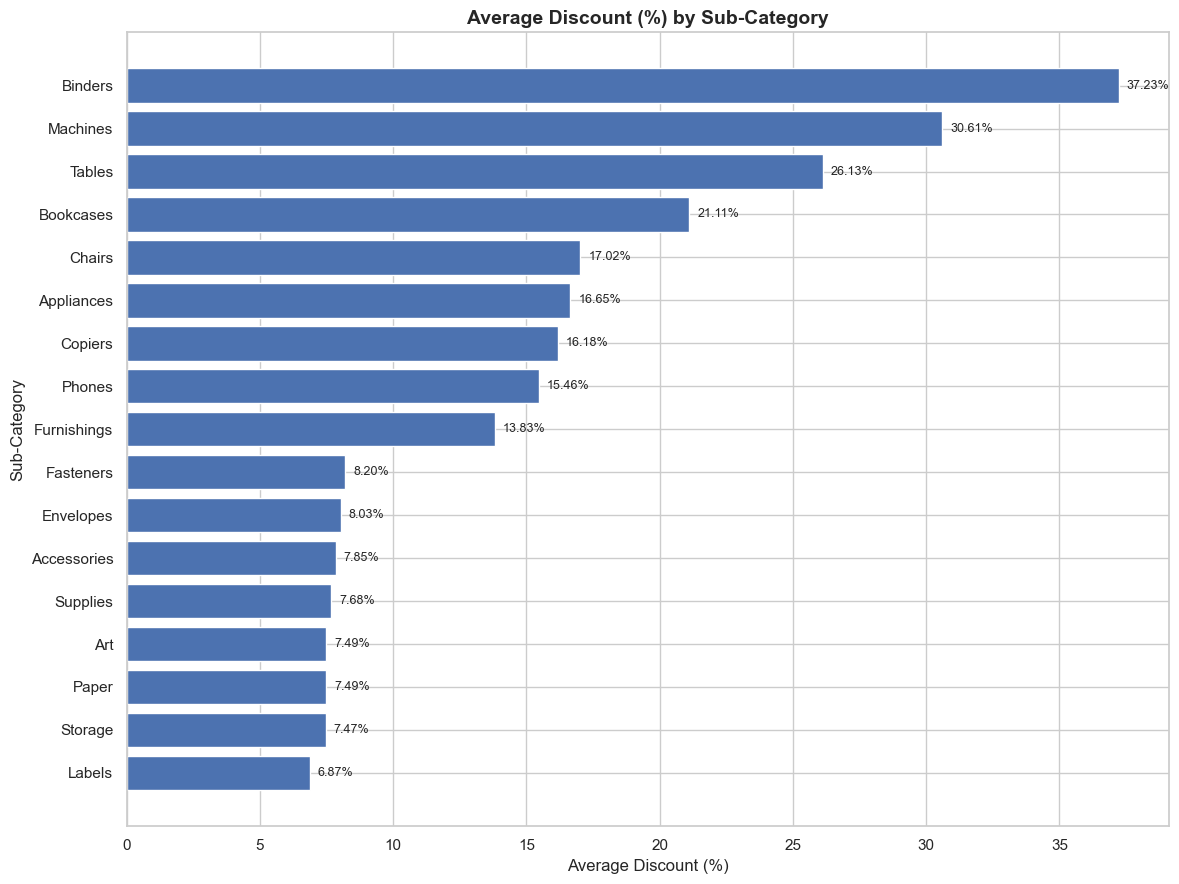

In [16]:
# DISCOUNT BY SUB-CATEGORY

plt.figure(figsize=(12, 9))

colors_sub = [
    '#C44E52' if p < 0 else '#4C72B0'
    for p in subcat_discount['Avg_Discount_%']
]

bars = plt.barh(
    subcat_discount['Sub-Category'],
    subcat_discount['Avg_Discount_%'],
    color='#4C72B0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        format_percent(width),
        va='center', fontsize=9
    )

plt.title('Average Discount (%) by Sub-Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Discount (%)')
plt.ylabel('Sub-Category')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('subcat_avg_discount.png')
plt.show()

In [17]:
category_discount.to_csv(
    'reports/tables/category_discount_analysis.csv', index=False
)

subcat_discount.to_csv(
    'reports/tables/subcat_discount_analysis.csv', index=False
)

print("Discount analysis tables saved")

Discount analysis tables saved


### Insight



### Recommendation



## 5. Discount Impact by Region

Business question:

**How do discount levels vary across regions 
and how does this affect profitability?**

In [18]:
# DISCOUNT BY REGION

region_discount = df.groupby('Region').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Avg_Discount = ('Discount', 'mean'),
    Avg_Profit   = ('Profit',   'mean')
).reset_index()

region_discount['Profit_Margin_%'] = (
    region_discount['Total_Profit'] /
    region_discount['Total_Sales'] * 100
).round(2)

region_discount['Avg_Discount_%'] = (
    region_discount['Avg_Discount'] * 100
).round(2)

region_discount = region_discount.sort_values(
    'Avg_Discount_%', ascending=False
).reset_index(drop=True)

region_discount

,Region,Total_Sales,Total_Profit,Avg_Discount,Avg_Profit,Profit_Margin_%,Avg_Discount_%
0,Central,501239.89,39706.36,0.24,17.09,7.92,24.04
1,South,391721.91,46749.43,0.15,28.86,11.93,14.73
2,East,678781.24,91522.78,0.15,32.14,13.48,14.54
3,West,725457.82,108418.45,0.11,33.85,14.94,10.93


Saved: images/region_discount_profit_margin.png


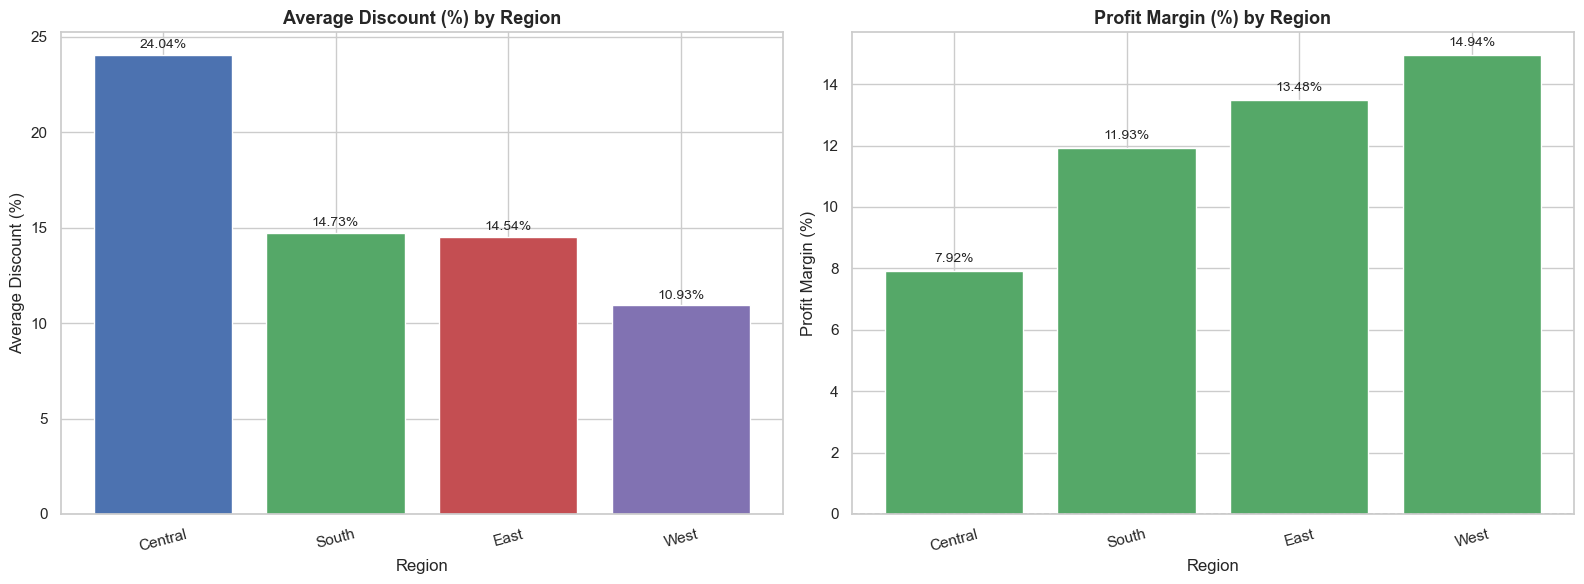

In [19]:
# DISCOUNT vs PROFIT MARGIN BY REGION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_region = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Avg Discount
bars1 = axes[0].bar(
    region_discount['Region'],
    region_discount['Avg_Discount_%'],
    color=colors_region,
    edgecolor='white'
)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        format_percent(height),
        ha='center', va='bottom', fontsize=10
    )

axes[0].set_title('Average Discount (%) by Region',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Average Discount (%)')
axes[0].tick_params(axis='x', rotation=15)

# Profit Margin
colors_margin_region = [
    '#C44E52' if m < 0 else '#55A868'
    for m in region_discount['Profit_Margin_%']
]

bars2 = axes[1].bar(
    region_discount['Region'],
    region_discount['Profit_Margin_%'],
    color=colors_margin_region,
    edgecolor='white'
)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        format_percent(height),
        ha='center', va='bottom', fontsize=10
    )

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Profit Margin (%) by Region',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('region_discount_profit_margin.png')
plt.show()

## 6. Discount Impact by Segment

Business question:

**Which customer segment receives the highest discounts?**

In [20]:
# DISCOUNT BY SEGMENT

segment_discount = df.groupby('Segment').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Avg_Discount = ('Discount', 'mean'),
    Avg_Profit   = ('Profit',   'mean')
).reset_index()

segment_discount['Profit_Margin_%'] = (
    segment_discount['Total_Profit'] /
    segment_discount['Total_Sales'] * 100
).round(2)

segment_discount['Avg_Discount_%'] = (
    segment_discount['Avg_Discount'] * 100
).round(2)

segment_discount = segment_discount.sort_values(
    'Avg_Discount_%', ascending=False
).reset_index(drop=True)

segment_discount

,Segment,Total_Sales,Total_Profit,Avg_Discount,Avg_Profit,Profit_Margin_%,Avg_Discount_%
0,Corporate,706146.37,91979.13,0.16,30.46,13.03,15.82
1,Consumer,1161401.34,134119.21,0.16,25.84,11.55,15.81
2,Home Office,429653.15,60298.68,0.15,33.82,14.03,14.71


Saved: images/segment_discount_profit_margin.png


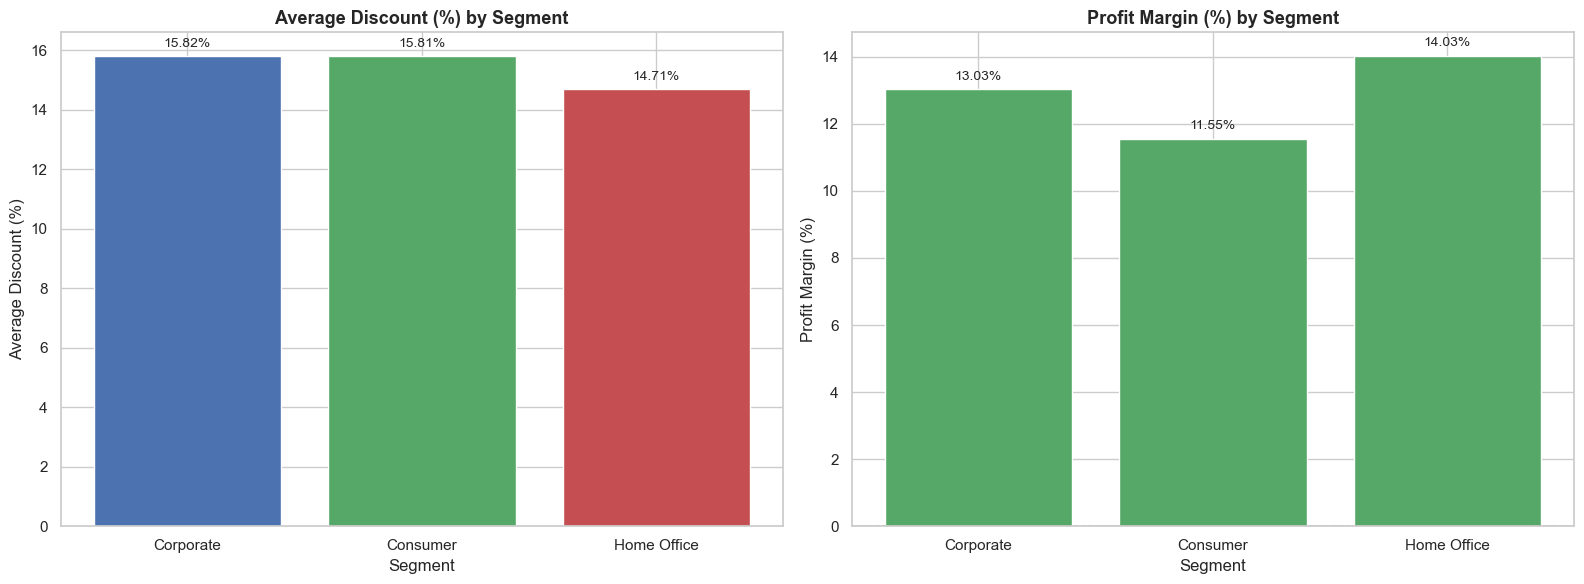

In [21]:
# DISCOUNT vs PROFIT MARGIN BY SEGMENT 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_seg = ['#4C72B0', '#55A868', '#C44E52']

# Avg Discount
bars1 = axes[0].bar(
    segment_discount['Segment'],
    segment_discount['Avg_Discount_%'],
    color=colors_seg,
    edgecolor='white'
)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        format_percent(height),
        ha='center', va='bottom', fontsize=10
    )

axes[0].set_title('Average Discount (%) by Segment',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Average Discount (%)')

# Profit Margin
colors_margin_seg = [
    '#C44E52' if m < 0 else '#55A868'
    for m in segment_discount['Profit_Margin_%']
]

bars2 = axes[1].bar(
    segment_discount['Segment'],
    segment_discount['Profit_Margin_%'],
    color=colors_margin_seg,
    edgecolor='white'
)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        format_percent(height),
        ha='center', va='bottom', fontsize=10
    )

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Profit Margin (%) by Segment',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Profit Margin (%)')

plt.tight_layout()
save_fig('segment_discount_profit_margin.png')
plt.show()

In [22]:
region_discount.to_csv(
    'reports/tables/region_discount_analysis.csv', index=False
)

segment_discount.to_csv(
    'reports/tables/segment_discount_analysis.csv', index=False
)

print("Region and Segment discount tables saved")

Region and Segment discount tables saved


## 7. Final Recommendations

Based on the full discount and profitability analysis, 
we summarize the key findings and actionable recommendations.

In [23]:
# FINAL RECOMMENDATIONS SUMMARY 

# Find the discount band where profit turns negative
loss_bands = discount_band_analysis[
    discount_band_analysis['Total_Profit'] < 0
]['Discount_Band'].tolist()

# Category with highest avg discount
highest_discount_category = category_discount.iloc[0]

# Sub-category with highest avg discount
highest_discount_subcat = subcat_discount.iloc[0]

# Region with highest avg discount
highest_discount_region = region_discount.iloc[0]

print("=" * 60)
print("DISCOUNT & PROFITABILITY — KEY FINDINGS")
print("=" * 60)

print(f"\n📉 Discount Bands causing losses:")
for band in loss_bands:
    print(f"   ⚠️  {band}")

print(f"\n📦 Highest discounted Category:")
print(f"   {highest_discount_category['Category']} — "
      f"Avg Discount: "
      f"{format_percent(highest_discount_category['Avg_Discount_%'])}")

print(f"\n🏷️ Highest discounted Sub-Category:")
print(f"   {highest_discount_subcat['Sub-Category']} — "
      f"Avg Discount: "
      f"{format_percent(highest_discount_subcat['Avg_Discount_%'])}")

print(f"\n🌍 Highest discounted Region:")
print(f"   {highest_discount_region['Region']} — "
      f"Avg Discount: "
      f"{format_percent(highest_discount_region['Avg_Discount_%'])}")


DISCOUNT & PROFITABILITY — KEY FINDINGS

📉 Discount Bands causing losses:
   ⚠️  21–30% — Medium
   ⚠️  31–40% — High
   ⚠️  41%+ — Very High

📦 Highest discounted Category:
   Furniture — Avg Discount: 17.39%

🏷️ Highest discounted Sub-Category:
   Binders — Avg Discount: 37.23%

🌍 Highest discounted Region:
   Central — Avg Discount: 24.04%


## Summary

This notebook completed the discount and profitability 
analysis for the Superstore Sales dataset.

### Key Areas Covered
- Overall discount distribution
- Discount vs Profit relationship and correlation
- Discount band profitability analysis
- Category-level discount impact
- Sub-category discount concentration
- Regional discount patterns
- Segment discount behavior
- Strategic recommendations

### Main Takeaways
- High discounts are the driver of losses 
  in the Superstore business.
- A clear discount policy with defined thresholds 
  is needed to protect profit margins.
- The discount issue is concentrated in specific 
  categories, sub-categories, and regions 
  that can be targeted for immediate action.

### Next Steps:
- SQL Queries
